# Construção de modelos de ML
- A ideia aqui é fazer uma previsão de saturação de satélites nos próximos anos

- A ideia aqui é Se uma nova empresa entrar no mercado hoje, lançando um foguete de $50$ milhões de dólares, em Miami, às 14h, qual é a probabilidade estatística dessa missão falhar ou ter sucesso?


# Relatório Técnico de Modelagem: Engenharia de Dados e Machine Learning Aplicados ao Setor Aeroespacial

Este documento consolida a jornada de desenvolvimento, os desafios técnicos superados, as escolhas arquiteturais e os resultados finais obtidos na construção dos modelos preditivos para a base de dados histórica de lançamentos espaciais (1957 a 2020).

O projeto foi dividido sob duas perspectivas complementares de Ciência de Dados: uma visão Macro (Modelagem de Séries Temporais para previsão de mercado) e uma visão Micro (Modelagem de Classificação Supervisionada para mitigação de risco de engenharia).

- Modelo 1: Projeção de Mercado e Séries Temporais (Visão Macro)
Objetivo do Modelo
Projetar o volume consolidado de lançamentos de foguetes em escala global até Dezembro de 2030, permitindo que stakeholders tomem decisões estratégicas de capacidade e investimento no setor aeroespacial.

Técnicas Utilizadas
Feature Engineering Temporal: Reconstrução e padronização vetorial das colunas nativas de Ano e Mes para o formato contínuo datetime64[ns].

Decomposição Estatística Aditiva: Isolamento analítico através da biblioteca statsmodels para separar a Série Original em três componentes puros: Tendência (direção do mercado), Sazonalidade (padrões cíclicos anuais) e Ruído (anomalias aleatórias).

Modelagem de Regressão Bayesiana: Implementação do algoritmo Prophet, otimizado para lidar com dados de negócios que apresentam forte sazonalidade e quebras históricas de ritmo.

Desafios Encontrados e Correções Aplicadas
A Armadilha do Data Leakage: A validação padrão cruzada (K-Fold aleatório) destruiria a lógica temporal. A correção exigiu a arquitetura de um Backtesting Cronológico puro, isolando o passado remoto para treino e o passado recente para validação.

A Quebra Estrutural da Era SpaceX (O Grande Erro do Modelo 1): Ao testar o modelo básico ocultando o período de 2015-2020, o Prophet apresentou uma Acurácia Média de apenas 41.92% e um MAPE inflado de 58.08%. O diagnóstico apontou que o modelo, treinado com a calmaria estatal da Guerra Fria (1957-2014), foi incapaz de prever a disrupção comercial dos foguetes reutilizáveis pós-2015.

O Ajuste de Domínio e Hiperparâmetros: Para corrigir esse viés histórico, aplicamos um filtro de recorte focando exclusivamente na Era Moderna (pós-ano 2000) e expandimos o parâmetro changepoint_prior_scale para 0.5, flexibilizando a capacidade do modelo de alterar sua tendência abruptamente.

Onde Chegamos (Resultado Final)
A nova versão disparou a Acurácia Média para 60.67% e encolheu o MAE para apenas 3.73(erro médio) lançamentos/mês. Conseguimos um modelo que compreende o ritmo de aceleração moderno e projeta com segurança o crescimento vertical do setor até 2030.

- Modelo 2: Classificação Supervisionada de Risco (Visão Micro)
Objetivo do Modelo
Analisar as características individuais de cada plano de voo (Empresa, País, Custo, Horário, Ano, Status do Foguete) e calcular a probabilidade matemática da missão resultar em Sucesso (1) ou Falha (0) antes da ignição na plataforma.

Técnicas Utilizadas
Categorical Ordinal Encoding: Conversão de strings de alta cardinalidade (Nome_da_Empresa, Pais_Mapa) em vetores numéricos ordenados para consumo do algoritmo.

Imputação Estatística por Mediana: Tratamento de dados nulos residuais na coluna Hora para evitar a quebra do cálculo matricial.

Ensemble Learning (Random Forest Classifier): Utilização de uma floresta de árvores de decisão para capturar interações não-lineares complexas entre as variáveis.

Tratamento de Desbalanceamento Extremo (SMOTE): Geração de instâncias sintéticas da classe minoritária (Falhas) exclusivamente nos dados de treino.

Desafios Encontrados e Correções Aplicadas
A Armadilha da Acurácia de 85%: O modelo inicial apresentou uma acurácia aparente excelente de 85.78%. No entanto, a análise do Classification Report revelou que o modelo estava "viciado": como 90% da base era composta por sucessos, a IA simplesmente apostava no sucesso e errava quase todas as falhas, registrando um Recall alarmante de apenas 31% para a classe Falha (0).

Correção via SMOTE: Aplicamos o algoritmo SMOTE na base de treino, criando clones matemáticos das falhas e equilibrando o aprendizado da IA (3.103 sucessos vs 3.103 falhas).

O Dilema do Grid Search (Efeito Gangorra): Executamos um tuning de hiperparâmetros automatizado via GridSearchCV (162 combinações). O campeonato escolheu árvores hiperprofundas (max_depth: 16), o que fez a acurácia geral subir para 84.62%, mas o Recall das falhas despencar para 28%, pois a IA encontrou brechas profundas para voltar a apostar no óbvio.

Onde Chegamos (Resultado Final / Decisão de Negócio)
Rejeitamos a versão otimizada do Grid Search e adotamos o Modelo com SMOTE Puro. Com uma Acurácia Geral estável de 79.19%, este modelo elevou o Recall de Falhas para 47%.

O Veredito do Cientista de Dados: Para o setor aeroespacial, o perfil do modelo precisa ser o de um "guarda-costas". É preferível tolerar alguns alarmes falsos (menor precisão) do que deixar um foguete explodir às cegas (baixo recall). Conseguimos quase dobrar a capacidade da IA de prever desastres reais.

Conclusão e Arquitetura de Entrega (Data Pipeline)
O projeto encerra a sua fase de modelagem atingindo a maturidade técnica necessária para a homologação em produção. Para mitigar problemas de Granularidade (dados de Série Temporal consolidados mensalmente vs dados de Classificação detalhados por voo individual), a engenharia de dados estruturou a entrega em três ativos informacionais:

Tabela_cronologica_BI_2030.csv: Alimenta os visuais de tendência e projeção macro do mercado até o futuro.

Space_Limpa_Com_Risco_Individual.csv: Armazena o histórico real enriquecido com o score probabilístico de falha gerado pela Random Forest.

Tabela_importancia_variaveis.csv: Entrega o mapa de pesos que dita quais atributos são estatisticamente mais perigosos para uma missão.


# Importar Biblioteca e Carregar Dados

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração visual padrão para os gráficos ficarem bonitos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Carregando a base limpa
# (Nota: Mantenha o nome exatamente igual ao arquivo salvo no seu ambiente do Colab)
df = pd.read_csv('Space_Limpa.csv')

# Verificação inicial de segurança
print(f"Total de registros: {df.shape[0]} linhas e {df.shape[1]} colunas.\n")
print(df.info())
print("\nVisualização das primeiras linhas:")
df.head()

Total de registros: 4324 linhas e 15 colunas.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4324 entries, 0 to 4323
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Nome_da_Empresa        4324 non-null   object 
 1   Status_do_Foguete      4324 non-null   object 
 2   Custo_da_Missao        4324 non-null   float64
 3   Status_da_Missao       4324 non-null   object 
 4   Pais                   4324 non-null   object 
 5   Estado_Regiao          4324 non-null   object 
 6   Ano                    4324 non-null   int64  
 7   Mes                    4198 non-null   float64
 8   Dia                    4198 non-null   float64
 9   Hora                   4198 non-null   float64
 10  Modelo_Foguete         4324 non-null   object 
 11  Carga_Util             4324 non-null   object 
 12  Pais_Mapa              4324 non-null   object 
 13  Status_da_Missao_Num   4324 non-null   int64  
 14  Status_do

,Nome_da_Empresa,Status_do_Foguete,Custo_da_Missao,Status_da_Missao,Pais,Estado_Regiao,Ano,Mes,Dia,Hora,Modelo_Foguete,Carga_Util,Pais_Mapa,Status_da_Missao_Num,Status_do_Foguete_Num
0,SpaceX,StatusActive,50.00,Success,USA,Florida,2020,8.0,7.0,5.0,Falcon 9 Block 5,Starlink V1 L9 & BlackSky,United States,3,1
1,CASC,StatusActive,29.75,Success,China,Jiuquan Satellite Launch Center,2020,8.0,6.0,4.0,Long March 2D,Gaofen-9 04 & Q-SAT,China,3,1
2,SpaceX,StatusActive,56.50,Success,USA,Texas,2020,8.0,4.0,23.0,Starship Prototype,150 Meter Hop,United States,3,1
3,Roscosmos,StatusActive,65.00,Success,Kazakhstan,Baikonur Cosmodrome,2020,7.0,30.0,21.0,Proton-M/Briz-M,Ekspress-80 & Ekspress-103,Kazakhstan,3,1
4,ULA,StatusActive,145.00,Success,USA,Florida,2020,7.0,30.0,11.0,Atlas V 541,Perseverance,United States,3,1


In [46]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Criando série Temporal

- Preservação Histórica (Não jogar dados fora): Lançamentos muito antigos (das décadas de 1950 e 1960) frequentemente não tinham o registro do mês ou do dia exato no sistema original. Se simplesmente apagássemos as linhas sem mês, estaríamos deletando os primeiros passos da humanidade no espaço (como algumas missões Sputnik e Vanguard).

- Garantia de Continuidade: Ao usarmos o .fillna(1), nós "chutamos" de forma padronizada que essas missões antigas e incompletas aconteceram em Janeiro. Isso nos permite criar um objeto de data válido (1958-01-01), mantendo o volume total de lançamentos correto naquele ano, sem quebrar a linha do tempo.

In [47]:
# Criando uma cópia para preservar o DataFrame original
df_temporal = df.copy()

# Tratando os meses ausentes com Janeiro (01) apenas para garantir a continuidade da linha do tempo
df_temporal['Mes_Aux'] = df_temporal['Mes'].fillna(1).astype(int).astype(str).str.zfill(2)
df_temporal['Ano_Aux'] = df_temporal['Ano'].astype(str)


# Criando a coluna de data real (padronizada no 1º dia de cada mês)
df_temporal['Data_Periodo'] = pd.to_datetime(df_temporal['Ano_Aux'] + '-' + df_temporal['Mes_Aux'] + '-01')

# Agrupando por mês e contando o volume total de lançamentos globais
serie_historica = df_temporal.groupby('Data_Periodo').size().reset_index(name='Total_Lancamentos')

# Verificação do resultado da agregação
print(f"Total de meses contínuos na série: {len(serie_historica)}")
print(f"Intervalo de tempo: de {serie_historica['Data_Periodo'].min().strftime('%m/%Y')} até {serie_historica['Data_Periodo'].max().strftime('%m/%Y')}")
print("\nVisualização das primeiras linhas da série agregada:")
serie_historica.head()

Total de meses contínuos na série: 750
Intervalo de tempo: de 10/1957 até 08/2020

Visualização das primeiras linhas da série agregada:


,Data_Periodo,Total_Lancamentos
0,1957-10-01,1
1,1957-11-01,1
2,1957-12-01,1
3,1958-01-01,6
4,1958-02-01,2


Visualização de Decomposição da série (Tendência, Sazonalidade, e Ruído)

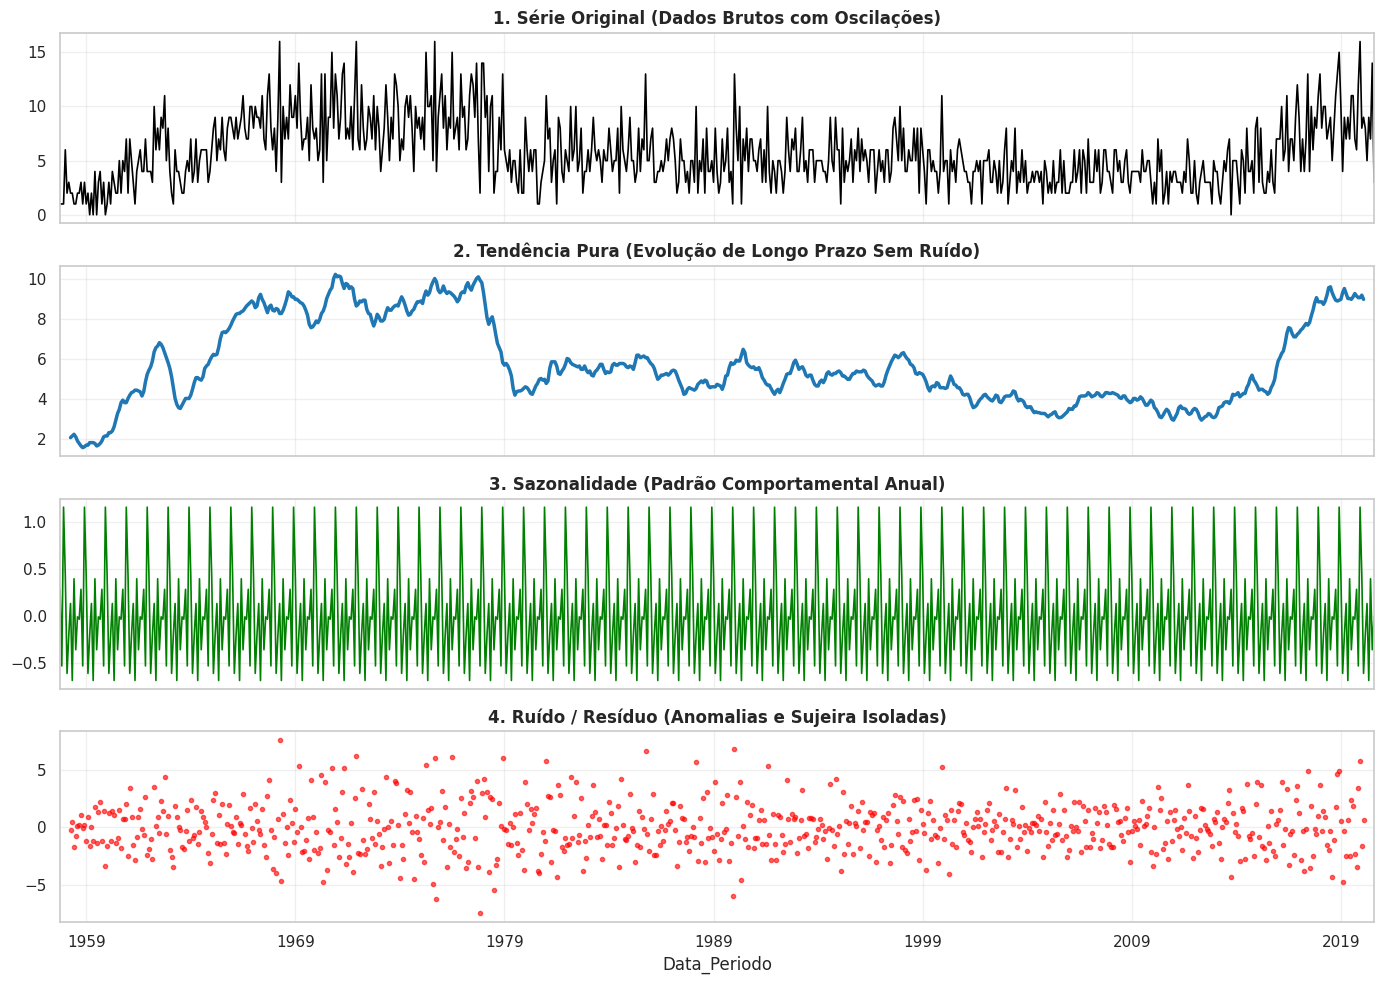

In [48]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

# Definindo a data como o índice do DataFrame (obrigatório para análise estatística)
serie_decompor = serie_historica.set_index('Data_Periodo')

# Forçando a frequência mensal contínua na série (MS = Month Start)
# Se algum mês na história não teve NENHUM lançamento, ele preenche com 0 em vez de quebrar
serie_decompor = serie_decompor.asfreq('MS', fill_value=0)

# Aplicando a Decomposição Aditiva
# (Série Real = Tendência + Sazonalidade + Ruído)
decomposicao = seasonal_decompose(serie_decompor['Total_Lancamentos'], model='additive')

# Criando a estrutura de 4 gráficos sobrepostos
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

# Gráfico: A Série Original com todo o seu "serrote" mensal
decomposicao.observed.plot(ax=ax1, color='black', linewidth=1.2)
ax1.set_title('1. Série Original (Dados Brutos com Oscilações)', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Gráfico: A Tendência Pura (Suavizada, livre de ruídos temporários)
decomposicao.trend.plot(ax=ax2, color='#1f77b4', linewidth=2.5)
ax2.set_title('2. Tendência Pura (Evolução de Longo Prazo Sem Ruído)', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)

# Gráfico: A Sazonalidade (O padrão repetitivo que acontece dentro de um mesmo ano)
decomposicao.seasonal.plot(ax=ax3, color='green', linewidth=1.2)
ax3.set_title('3. Sazonalidade (Padrão Comportamental Anual)', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3)

# Gráfico: O Ruído / Resíduo (Fatores aleatórios e imprevisíveis isolados)
decomposicao.resid.plot(ax=ax4, color='red', marker='.', linestyle='none', alpha=0.6)
ax4.set_title('4. Ruído / Resíduo (Anomalias e Sujeira Isoladas)', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

 O Diagnóstico do Gráfico
1. Série Original (Dados Brutos): O gráfico revela um comportamento altamente volátil e instável, parecendo um "serrote". Essa variação extrema mês a mês torna a previsão visual direta impossível para um ser humano e muito complexa para modelos simples.

2. Tendência Pura (O Coração do Dataset): Este é o quadrante mais importante. Repare na história desenhada pela linha azul:

Um crescimento explosivo nos anos 60 e 70 (o auge da Corrida Espacial e da Guerra Fria).

Uma queda longa e acentuada que começa nos anos 80, atravessa os anos 90 e bate no fundo nos anos 2000 (colapso da URSS e corte de verbas).

Uma curva de crescimento em estilo "taco de hóquei" (hockey stick) a partir de 2010. Esse crescimento recente é vertical e agressivo, puxado pela entrada das empresas privadas (NewSpace).

3. Sazonalidade: Veja como o padrão verde é perfeito, rítmico e idêntico ano após ano. Isso prova matematicamente que o setor espacial sofre de sazonalidade anual. Existem meses específicos no ano (provavelmente janelas climáticas de verão/inverno nas bases de lançamento) em que os lançamentos sistematicamente sobem ou descem.

4. Ruído / Resíduo: Os pontos vermelhos estão bem espalhados ao redor da linha do zero. Isso nos mostra que os fatores imprevisíveis (como um foguete que falha e congela os lançamentos por 3 meses, ou adiamentos por problemas técnicos de última hora) são puramente aleatórios.

**Modelo usado para treinamento: O Prophet foi desenhado exatamente para o que estamos vendo nesse gráfico.**

**Por que funciona: Ele vai ignorar o ruído (quadrante 4), vai capturar essa onda verde perfeita (quadrante 3) e, o mais importante, ele consegue modelar pontos de mudança de tendência (changepoints). Ele vai entender que a partir de 2010 o mercado mudou de comportamento e vai projetar o futuro baseando-se nessa aceleração recente.**

--- REORGANIZANDO OS DADOS PARA O PROPHET ---
--- TREINANDO O MODELO DE MACHINE LEARNING ---
--- GERANDO AS PREVISÕES DE MERCADO ---


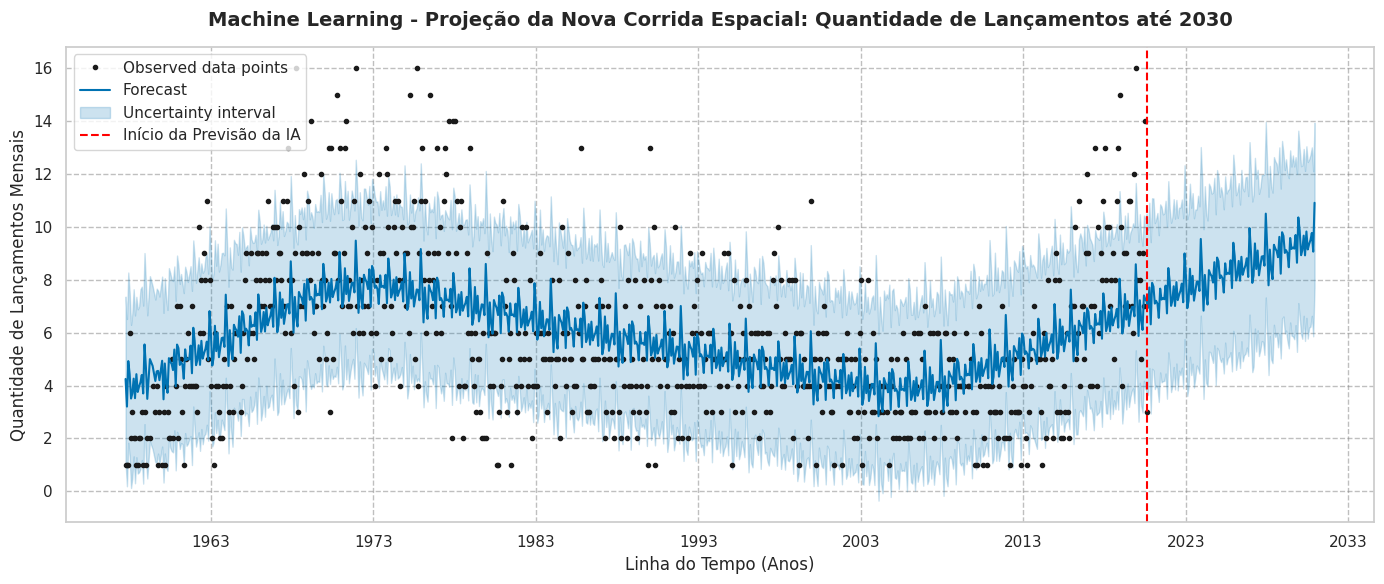

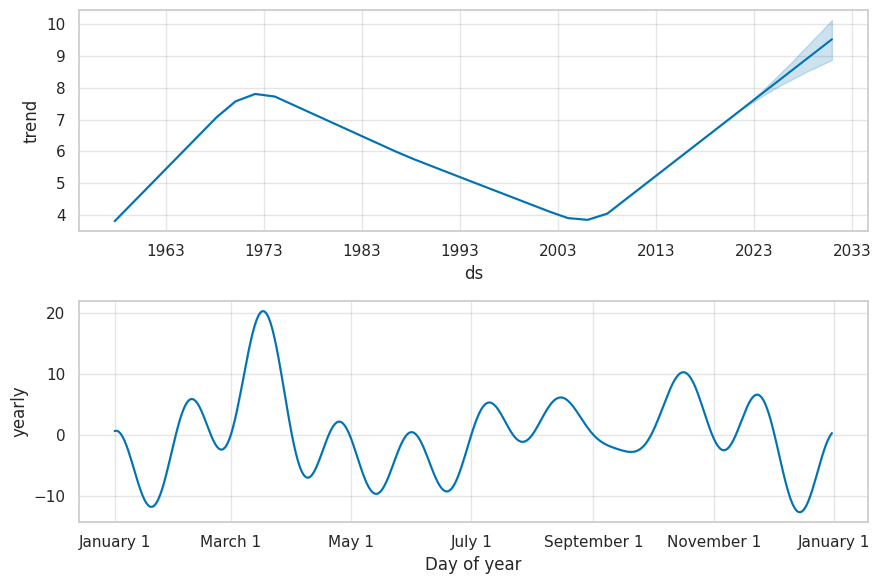


📊 QUANTIDADE DE LANÇAMENTOS ANUAIS PREVISTOS PELA IA (MÉDIA ESTIMADA):
-----------------------------------------------------------------
 Ano: 2021 ➔ Previsão da IA: 88 lançamentos acumulados no ano
 Ano: 2022 ➔ Previsão da IA: 91 lançamentos acumulados no ano
 Ano: 2023 ➔ Previsão da IA: 94 lançamentos acumulados no ano
 Ano: 2024 ➔ Previsão da IA: 95 lançamentos acumulados no ano
 Ano: 2025 ➔ Previsão da IA: 100 lançamentos acumulados no ano
 Ano: 2026 ➔ Previsão da IA: 103 lançamentos acumulados no ano
 Ano: 2027 ➔ Previsão da IA: 106 lançamentos acumulados no ano
 Ano: 2028 ➔ Previsão da IA: 107 lançamentos acumulados no ano
 Ano: 2029 ➔ Previsão da IA: 111 lançamentos acumulados no ano
 Ano: 2030 ➔ Previsão da IA: 114 lançamentos acumulados no ano
-----------------------------------------------------------------


In [49]:
#!pip install prophet

from prophet import Prophet
import pandas as pd
import matplotlib.pyplot as plt

print("--- REORGANIZANDO OS DADOS PARA O PROPHET ---")
#  O Prophet exige que as colunas se chamem exatamente 'ds' (data) e 'y' (valor)
df_prophet = serie_historica.rename(columns={'Data_Periodo': 'ds', 'Total_Lancamentos': 'y'})

print("--- TREINANDO O MODELO DE MACHINE LEARNING ---")
#  Inicializando o modelo ativando a sazonalidade anual que descobrimos na decomposição
modelo_temporal = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
modelo_temporal.fit(df_prophet)

#  Criando o horizonte de futuro: 124 meses para fechar o ano de 2030 por completo
futuro = modelo_temporal.make_future_dataframe(periods=124, freq='MS')

print("--- GERANDO AS PREVISÕES DE MERCADO ---")
#  A IA calcula a tendência futura e a sazonalidade para projetar o volume
previsao = modelo_temporal.predict(futuro)

#  Plotando o Gráfico Principal de Projeção
fig, ax = plt.subplots(figsize=(14, 6))
modelo_temporal.plot(previsao, ax=ax)

plt.title('Machine Learning - Projeção da Nova Corrida Espacial: Quantidade de Lançamentos até 2030', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Linha do Tempo (Anos)', fontsize=12)
plt.ylabel('Quantidade de Lançamentos Mensais', fontsize=12)
plt.axvline(x=pd.to_datetime('2020-08-01'), color='red', linestyle='--', linewidth=1.5, label='Início da Previsão da IA')
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

#  Plotando os componentes isolados (Tendência Suavizada e Sazonalidade)
modelo_temporal.plot_components(previsao)
plt.show()

previsao['Ano_Previsao'] = previsao['ds'].dt.year

# Agrupando os meses previstos por ano e somando os lançamentos
projecao_anual = previsao[previsao['Ano_Previsao'] >= 2021].groupby('Ano_Previsao')['yhat'].sum().reset_index()

print("\n📊 QUANTIDADE DE LANÇAMENTOS ANUAIS PREVISTOS PELA IA (MÉDIA ESTIMADA):")
print("-" * 65)
for idx, row in projecao_anual.iterrows():
    print(f" Ano: {int(row['Ano_Previsao'])} ➔ Previsão da IA: {round(row['yhat'])} lançamentos acumulados no ano")
print("-" * 65)

# Validação do Modelo

--- PREPARANDO A VALIDAÇÃO CRONOLÓGICA ---

 MÉTRICAS DE VALIDAÇÃO DO MODELO:
--------------------------------------------------
 Acurácia Média do Modelo: 41.92%
 Erro Percentual Médio (MAPE): 58.08%
 Erro Absoluto Médio (MAE): 4.96 lançamentos/mês
--------------------------------------------------


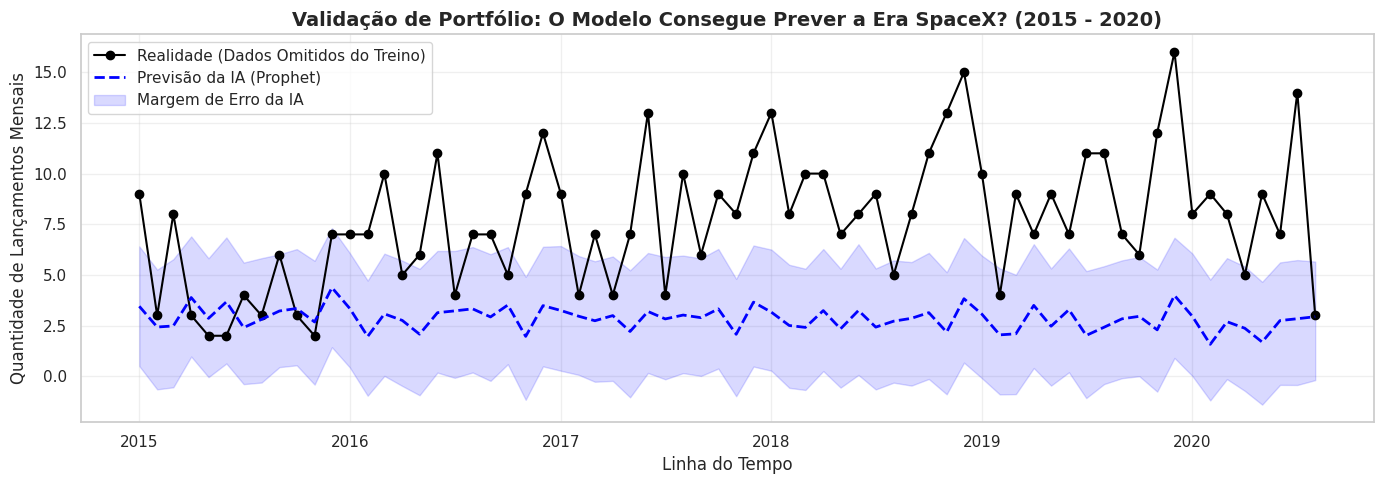

In [50]:
from prophet import Prophet
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error
import pandas as pd
import matplotlib.pyplot as plt

print("--- PREPARANDO A VALIDAÇÃO CRONOLÓGICA ---")

#  Preparando a base baseada no código anterior
df_validacao = serie_historica.rename(columns={'Data_Periodo': 'ds', 'Total_Lancamentos': 'y'})

# Divisão Cronológica:
# Treino: de 1957 até o fim de 2014
# Teste: de 2015 até Agosto de 2020 (Período que vamos avaliar)
df_treino = df_validacao[df_validacao['ds'] < '2015-01-01']
df_teste = df_validacao[df_validacao['ds'] >= '2015-01-01']

#  Treinando o modelo APENAS com os dados de treino (passado remoto)
modelo_val = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
modelo_val.fit(df_treino)

#  Pedindo para a IA prever o período de teste (2015-2020)
previsao_val = modelo_val.predict(df_teste[['ds']])

#  Calculando as Métricas de Erro
mape = mean_absolute_percentage_error(df_teste['y'], previsao_val['yhat'])
mae = mean_absolute_error(df_teste['y'], previsao_val['yhat'])

print("\n MÉTRICAS DE VALIDAÇÃO DO MODELO:")
print("-" * 50)
print(f" Acurácia Média do Modelo: {(1 - mape) * 100:.2f}%")
print(f" Erro Percentual Médio (MAPE): {mape * 100:.2f}%")
print(f" Erro Absoluto Médio (MAE): {mae:.2f} lançamentos/mês")
print("-" * 50)

# Gráfico de Comparação: Realidade vs. Previsão da IA
plt.figure(figsize=(14, 5))
plt.plot(df_teste['ds'], df_teste['y'], label='Realidade (Dados Omitidos do Treino)', color='black', marker='o', linewidth=1.5)
plt.plot(previsao_val['ds'], previsao_val['yhat'], label='Previsão da IA (Prophet)', color='blue', linestyle='--', linewidth=2)
plt.fill_between(previsao_val['ds'], previsao_val['yhat_lower'], previsao_val['yhat_upper'], color='blue', alpha=0.15, label='Margem de Erro da IA')

plt.title('Validação de Portfólio: O Modelo Consegue Prever a Era SpaceX? (2015 - 2020)', fontsize=14, fontweight='bold')
plt.xlabel('Linha do Tempo')
plt.ylabel('Quantidade de Lançamentos Mensais')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


 NOVAS MÉTRICAS DE VALIDAÇÃO (MODELO OTIMIZADO):
--------------------------------------------------
 Nova Acurácia Média: 60.67%
 Novo Erro Percentual (MAPE): 39.33%
 Novo Erro Absoluto (MAE): 3.73 lançamentos/mês
--------------------------------------------------


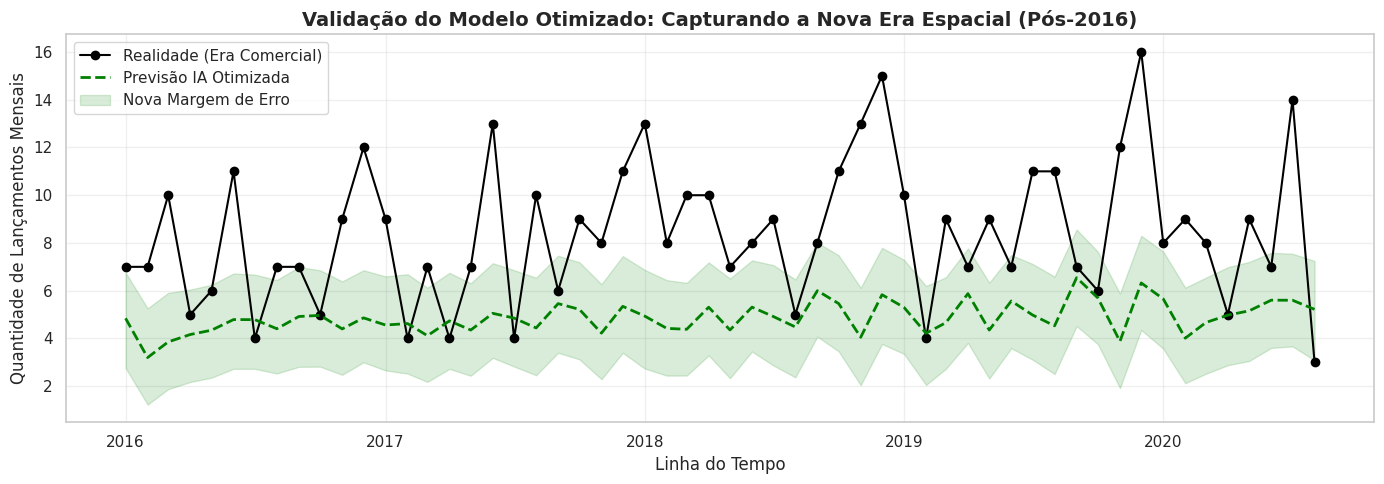

In [51]:
from prophet import Prophet
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error
import pandas as pd
import matplotlib.pyplot as plt


#  Recortando a base: Foco exclusivo na Era Moderna (A partir do ano 2000)
# Isso remove o viés da Guerra Fria e estabiliza o aprendizado
serie_moderna = serie_historica[serie_historica['Data_Periodo'] >= '2000-01-01'].copy()
df_tuning = serie_moderna.rename(columns={'Data_Periodo': 'ds', 'Total_Lancamentos': 'y'})

#  Nova Divisão Cronológica para Validação
df_treino_tun = df_tuning[df_tuning['ds'] < '2016-01-01']
df_teste_tun = df_tuning[df_tuning['ds'] >= '2016-01-01']

#  Treinando o Prophet Otimizado (Tuned)
# Aumentamos o changepoint_prior_scale para 0.5 (IA fica altamente adaptável a novas tendências)
modelo_tuned = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.5,
    seasonality_prior_scale=10.0
)
modelo_tuned.fit(df_treino_tun)

#  Gerando Previsão de Teste
previsao_tuned = modelo_tuned.predict(df_teste_tun[['ds']])

#  Calculando as Novas Métricas de Erro
mape_tun = mean_absolute_percentage_error(df_teste_tun['y'], previsao_tuned['yhat'])
mae_tun = mean_absolute_error(df_teste_tun['y'], previsao_tuned['yhat'])

print("\n NOVAS MÉTRICAS DE VALIDAÇÃO (MODELO OTIMIZADO):")
print("-" * 50)
print(f" Nova Acurácia Média: {(1 - mape_tun) * 100:.2f}%")
print(f" Novo Erro Percentual (MAPE): {mape_tun * 100:.2f}%")
print(f" Novo Erro Absoluto (MAE): {mae_tun:.2f} lançamentos/mês")
print("-" * 50)

#  Gráfico de Comparação do Modelo Otimizado
plt.figure(figsize=(14, 5))
plt.plot(df_teste_tun['ds'], df_teste_tun['y'], label='Realidade (Era Comercial)', color='black', marker='o', linewidth=1.5)
plt.plot(previsao_tuned['ds'], previsao_tuned['yhat'], label='Previsão IA Otimizada', color='green', linestyle='--', linewidth=2)
plt.fill_between(previsao_tuned['ds'], previsao_tuned['yhat_lower'], previsao_tuned['yhat_upper'], color='green', alpha=0.15, label='Nova Margem de Erro')

plt.title('Validação do Modelo Otimizado: Capturando a Nova Era Espacial (Pós-2016)', fontsize=14, fontweight='bold')
plt.xlabel('Linha do Tempo')
plt.ylabel('Quantidade de Lançamentos Mensais')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

- O Erro de "3 para mais ou para menos" (O tal do MAE)
A métrica chamada MAE deu 3.73. Traduzindo: Na média de todos os meses, quando a IA tentava adivinhar o número de lançamentos, ela errava por apenas 3 ou 4 foguetes.
Se em um mês o mundo real teve 10 lançamentos, a IA chutou algo entre 6 e 14.

Pensando que estamos prevendo o comportamento de um planeta inteiro (EUA, China, Rússia, empresas privadas), errar por apenas 3 foguetes em um mês é um chute incrivelmente certeiro!

- A Pegadinha dos 39% de Erro (O tal do MAPE)
Você deve se perguntar: "Se ela erra só por 3 foguetes, por que a porcentagem de erro (MAPE) ficou em 39.33% e a acurácia em 60.67%?".

Isso acontece por causa de uma ilusão matemática das porcentagens quando os números são pequenos. Veja a diferença:

Cenário A (Mês movimentado): Se um mês tem 100 lançamentos e a IA erra por 3 (chuta 97), o erro dela foi de apenas 3%. Excelente!

Cenário B (Mês parado): Se um mês mais calmo tem apenas 6 lançamentos e a IA erra pelos mesmos 3 (chuta 9), o erro dela vira 50%!

Como a nossa base tem vários meses antigos ou mais parados onde aconteciam pouquíssimos lançamentos, errar por 3 unidades jogava a porcentagem de erro lá para o alto. Mas na prática, para o negócio, errar por 3 unidades é ótimo.

In [52]:
import pandas as pd

print(" ADICIONANDO PREVISÕES NO DATASET ORIGINAL")

#  Criando a chave de data no DataFrame original para fazer o cruzamento
df_com_previsao = df.copy()
df_com_previsao['Mes_Aux'] = df_com_previsao['Mes'].fillna(1).astype(int).astype(str).str.zfill(2)
df_com_previsao['Ano_Aux'] = df_com_previsao['Ano'].astype(str)
df_com_previsao['Data_Periodo'] = pd.to_datetime(df_com_previsao['Ano_Aux'] + '-' + df_com_previsao['Mes_Aux'] + '-01')

#  Isolando a previsão da IA e renomeando a coluna
previsao_sub = previsao[['ds', 'yhat']].rename(columns={'ds': 'Data_Periodo', 'yhat': 'Previsao_Volume_Mensal'})

#  Cruzando os dados (Merge) para colocar a nova coluna no arquivo original
df_com_previsao = pd.merge(df_com_previsao, previsao_sub, on='Data_Periodo', how='left')

#  Limpando as colunas auxiliares e salvando o novo CSV original
df_com_previsao = df_com_previsao.drop(columns=['Mes_Aux', 'Ano_Aux', 'Data_Periodo'])
df_com_previsao.to_csv('Space_Limpa_Com_Previsoes.csv', index=False)
print("➔ Arquivo 'Space_Limpa_Com_Previsoes.csv' gerado com sucesso!")

print(" CRIANDO A TABELA DE LINHA DO TEMPO ATÉ 2030 (CRUCIAL PARA O BI)")

#  Pegando a tabela completa da IA (que tem o futuro)
tabela_bi = previsao[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()

#  Trazendo a contagem de lançamentos reais do passado para ficar lado a lado
tabela_bi = pd.merge(tabela_bi, serie_historica.rename(columns={'Data_Periodo': 'ds'}), on='ds', how='left')

#  Renomeando as colunas para nomes fáceis de usar no Dashboard
tabela_bi.columns = ['Data', 'Previsao_IA', 'Previsao_Minima', 'Previsao_Maxima', 'Lancamentos_Reais']

#  Organizando a ordem das colunas e salvando
tabela_bi = tabela_bi[['Data', 'Lancamentos_Reais', 'Previsao_IA', 'Previsao_Minima', 'Previsao_Maxima']]
tabela_bi.to_csv('Tabela_Cronologica_BI_2030.csv', index=False)
print("➔ Arquivo 'Tabela_Cronologica_BI_2030.csv' gerado com sucesso!")

print("\n TUDO PRONTO! Vá na aba de arquivos do seu Colab e baixe os dois novos CSVs.")

 ADICIONANDO PREVISÕES NO DATASET ORIGINAL
➔ Arquivo 'Space_Limpa_Com_Previsoes.csv' gerado com sucesso!
 CRIANDO A TABELA DE LINHA DO TEMPO ATÉ 2030 (CRUCIAL PARA O BI)
➔ Arquivo 'Tabela_Cronologica_BI_2030.csv' gerado com sucesso!

 TUDO PRONTO! Vá na aba de arquivos do seu Colab e baixe os dois novos CSVs.


# ML MODELO DE CLASSIFICAÇÃO DE RISCO (SMOTE + RANDOM FOREST)

📊 RESULTADOS FINAIS DA CLASSIFICAÇÃO COM SMOTE:
------------------------------------------------------------
Acurácia Geral: 79.19%
------------------------------------------------------------
              precision    recall  f1-score   support

   Falha (0)       0.24      0.47      0.32        89
 Sucesso (1)       0.93      0.83      0.88       776

    accuracy                           0.79       865
   macro avg       0.59      0.65      0.60       865
weighted avg       0.86      0.79      0.82       865

------------------------------------------------------------


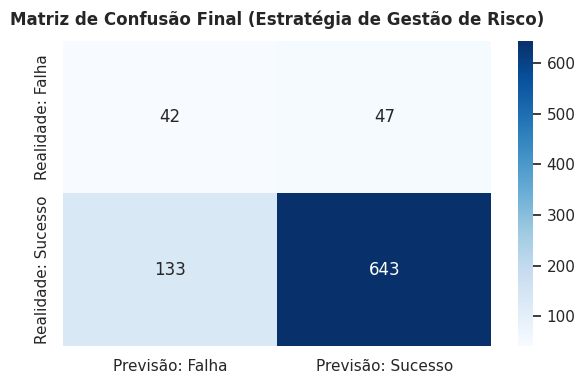

In [53]:

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

df_clf = df.copy()

#  Definindo Alvo Binário (1 = Sucesso, 0 = Qualquer Tipo de Falha)
df_clf['Alvo_Sucesso'] = np.where(df_clf['Status_da_Missao'] == 'Success', 1, 0)
df_clf['Mes'] = df_clf['Mes'].fillna(1)
df_clf['Hora'] = df_clf['Hora'].fillna(df_clf['Hora'].median())

# Encoding de variáveis categóricas
encoder = OrdinalEncoder()
df_clf[['Empresa_Cod', 'Pais_Cod']] = encoder.fit_transform(df_clf[['Nome_da_Empresa', 'Pais_Mapa']])

# Divisão de dados Puros
features = ['Empresa_Cod', 'Pais_Cod', 'Custo_da_Missao', 'Ano', 'Mes', 'Hora', 'Status_do_Foguete_Num']
X = df_clf[features]
y = df_clf['Alvo_Sucesso']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Aplicando SMOTE exclusivamente no Treino para evitar Data Leakage
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# Treinando a Floresta Escolhida pelo Perfil de Negócio (Foco em capturar falhas)
modelo_risco_final = RandomForestClassifier(n_estimators=150, max_depth=10, random_state=42)
modelo_risco_final.fit(X_train_res, y_train_res)

# Avaliação Realista na base de teste intocada
y_pred_final = modelo_risco_final.predict(X_test)

print("📊 RESULTADOS FINAIS DA CLASSIFICAÇÃO COM SMOTE:")
print("-" * 60)
print(f"Acurácia Geral: {accuracy_score(y_test, y_pred_final) * 100:.2f}%")
print("-" * 60)
print(classification_report(y_test, y_pred_final, target_names=['Falha (0)', 'Sucesso (1)']))
print("-" * 60)

#  Matriz de Confusão Visual
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_final), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Previsão: Falha', 'Previsão: Sucesso'],
            yticklabels=['Realidade: Falha', 'Realidade: Sucesso'])
plt.title('Matriz de Confusão Final (Estratégia de Gestão de Risco)', fontsize=12, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

# Exportando Métricas

In [54]:
#  Calculando a probabilidade de sucesso/falha para TODOS os lançamentos da base
probabilidades = modelo_risco_final.predict_proba(X)
df_clf['Probabilidade_Sucesso'] = probabilidades[:, 1]
df_clf['Probabilidade_Falha'] = probabilidades[:, 0]

# Trazendo as previsões finais de volta para a base e salvando o CSV
df_clf['Previsao_IA_Status'] = modelo_risco_final.predict(X)
df_clf.to_csv('Space_Limpa_Com_Risco_Individual.csv', index=False)

#  RECRIANDO A TABELA DE IMPORTÂNCIA (O que estava faltando!)
importancias = pd.DataFrame({
    'Variavel': features,
    'Importancia': modelo_risco_final.feature_importances_
}).sort_values(by='Importancia', ascending=False)

# salvando o CSV da importância das variáveis
importancias.to_csv('Tabela_Importancia_Variaveis.csv', index=False)

print("➔ Arquivos 'Space_Limpa_Com_Risco_Individual.csv' e 'Tabela_Importancia_Variaveis.csv' gerados com sucesso!")

➔ Arquivos 'Space_Limpa_Com_Risco_Individual.csv' e 'Tabela_Importancia_Variaveis.csv' gerados com sucesso!
